In [6]:
from langgraph.graph import START, END, StateGraph
from langgraph.prebuilt import ToolNode, tools_condition
from langchain.tools import tool


In [7]:
from langchain_groq import ChatGroq
from typing import TypedDict, Annotated
from langgraph.graph.message import add_messages
from langchain_core.messages import AnyMessage

In [8]:
from dotenv import load_dotenv
import os
load_dotenv()

True

In [9]:
class AgentState(TypedDict):
    messages: Annotated[list[AnyMessage], add_messages]
    

In [10]:
llm = ChatGroq(model='openai/gpt-oss-120b',
               temperature=0,
               api_key=os.getenv('GROQ_API_KEY')) #type: ignore

In [11]:
from langchain_community.utilities import WikipediaAPIWrapper

C:\Users\BRUH\AppData\Local\Temp\ipykernel_19260\3254895870.py:1: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.utilities import WikipediaAPIWrapper


In [12]:
@tool
def search_wiki(query: str, top_k_results: int = 1):
    '''Search engine for wikipedia'''
    wiki_wrapper = WikipediaAPIWrapper(top_k_results=top_k_results) #type: ignore
    docs = wiki_wrapper.load(query)
    merged_content = ''
    for i, doc in enumerate(docs, start=1):
        doc_content = doc.page_content + f'\n[{i}]: {doc.metadata['source']}'
        merged_content += doc_content + "\n\n"
    
    return merged_content

In [13]:
content = search_wiki.invoke('alexander the great')

In [14]:
print(content)

Alexander III of Macedon (Ancient Greek: Ἀλέξανδρος, romanized: Aléxandros; 20/21 July 356 BC – 10/11 June 323 BC), most commonly known as Alexander the Great, was king of the ancient Greek kingdom of Macedon. He succeeded his father Philip II to the throne in 336 BC at the age of 20, and spent most of his reign conducting a lengthy military campaign throughout Asia and Egypt. By the age of 30, he had created one of the largest empires in history, stretching from Greece to northwestern India. He was undefeated in battle and is widely considered to be one of history's greatest and most successful military commanders.
Born in Pella, Macedon, Alexander was tutored by philosopher and polymath Aristotle until the age of 16. In 335 BC, shortly after assuming the throne of Macedon, he launched a campaign in the Balkans and reasserted control over Thrace and parts of Illyria before marching on the city of Thebes, which was subsequently destroyed. Alexander then assumed leadership of the League

In [15]:
tools = [search_wiki]

In [16]:
llm_with_tools = llm.bind_tools(tools)

In [17]:
def llm_node(state: AgentState):
    messages = state['messages']
    return {'messages': [llm_with_tools.invoke(messages)]}

In [18]:
tools_node = ToolNode(tools)

In [19]:
graph = StateGraph(AgentState)

#add nodes
graph.add_node('llm', llm_node)
graph.add_node('tools_node', tools_node)

#add edges
graph.add_edge(START, 'llm')
graph.add_conditional_edges(
    'llm',
    tools_condition,
    {'tools': 'tools_node', '__end__': END}
)
graph.add_edge('tools_node', 'llm')

app = graph.compile()

In [20]:
from IPython.display import Image, display

def draw_png(app):
    display(Image(app.get_graph().draw_mermaid_png()))

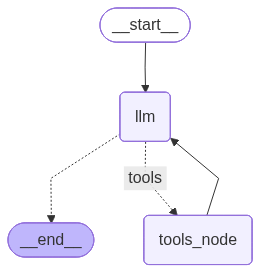

In [21]:
draw_png(app)

In [22]:
from langchain_core.messages import HumanMessage

In [23]:
result = app.invoke({
    'messages': [HumanMessage(content='Who is alexander the great?'),]
})

JSONDecodeError: Expecting value: line 1 column 1 (char 0)

In [ ]:
result

{'messages': [HumanMessage(content='Who is alexander the great?', additional_kwargs={}, response_metadata={}, id='81235dc3-b946-47a1-a855-46ad9da4e633'),
  AIMessage(content='', additional_kwargs={'tool_calls': [{'id': '8a8w50xyp', 'function': {'arguments': '{"query":"Alexander the Great"}', 'name': 'wikipedia'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 16, 'prompt_tokens': 288, 'total_tokens': 304, 'completion_time': 0.044683866, 'completion_tokens_details': None, 'prompt_time': 0.031918735, 'prompt_tokens_details': None, 'queue_time': 0.163336866, 'total_time': 0.076602601}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_3272ea2d91', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019e7324-36f3-74a3-9cd9-12f00e7b8979-0', tool_calls=[{'name': 'wikipedia', 'args': {'query': 'Alexander the Great'}, 'id': '8a8w50xyp', 'type': 'tool_call'}], invalid_tool_calls=[],